In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [12]:
# Load Dataset (class coloumn is empty so ignore)

DATA_PATH = "seeds_data.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

feature_cols = [f"Feature_{i}" for i in range(1, 8)]
X = df[feature_cols].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Data shape after preprocessing:", X.shape)

Data shape after preprocessing: (210, 7)


In [13]:
# K-means
class KMeansScratch:
    def __init__(self, k=3, max_iters=100, tol=1e-4, random_state=42):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None

    def _initialize_centroids(self, X):
        np.random.seed(self.random_state)
        indices = np.random.choice(len(X), self.k, replace=False)
        return X[indices]

    def _assign_clusters(self, X, centroids):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = np.array([
            X[labels == i].mean(axis=0) for i in range(self.k)
        ])
        return new_centroids

    def fit(self, X):
        self.centroids = self._initialize_centroids(X)

        for _ in range(self.max_iters):
            labels = self._assign_clusters(X, self.centroids)
            new_centroids = self._update_centroids(X, labels)

            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break

            self.centroids = new_centroids

        self.labels_ = labels
        return self

    def inertia(self, X):
        total = 0
        for i in range(self.k):
            cluster_points = X[self.labels_ == i]
            total += np.sum((cluster_points - self.centroids[i]) ** 2)
        return total

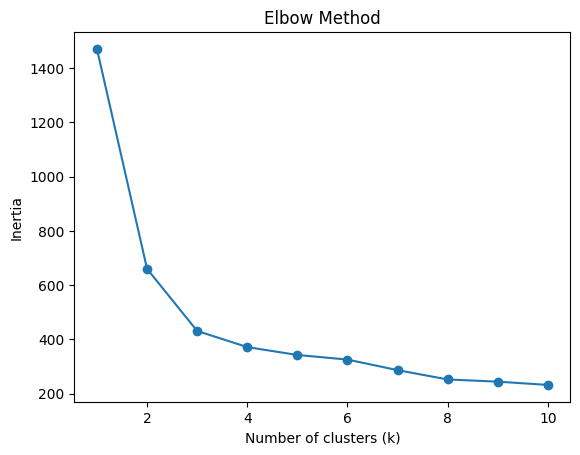

In [14]:
# Elbow Method to Find Optimal K

ks = range(1, 11)
inertias = []

for k in ks:
    model = KMeansScratch(k=k)
    model.fit(X)
    inertias.append(model.inertia(X))

plt.figure()
plt.plot(ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [15]:
K_OPT = 3   
kmeans = KMeansScratch(k=K_OPT)
kmeans.fit(X)

print("Cluster Centers (standardized feature space):")
print(kmeans.centroids)

Cluster Centers (standardized feature space):
[[-0.19329356 -0.22593177  0.42055402 -0.32042281 -0.03992186 -0.68865597
  -0.65371743]
 [-1.03705249 -1.011377   -0.99203529 -0.89389215 -1.10415374  0.78677237
  -0.59724824]
 [ 1.22652173  1.23574863  0.532724    1.21993524  1.13038768 -0.04679182
   1.28020657]]


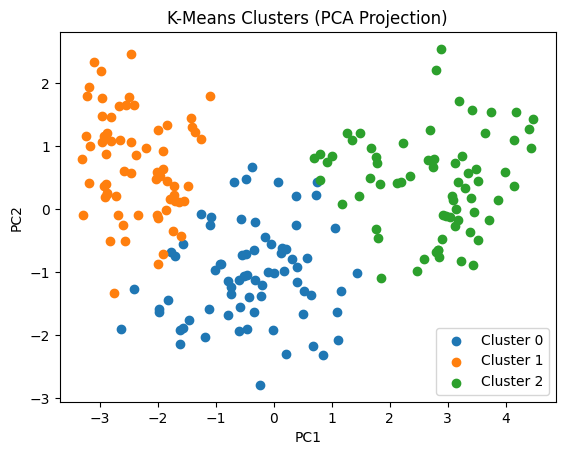

In [16]:
# PCA 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
for i in range(K_OPT):
    plt.scatter(
        X_pca[kmeans.labels_ == i, 0],
        X_pca[kmeans.labels_ == i, 1],
        label=f"Cluster {i}"
    )

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()